In [19]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 15b
## Sequential Modeling Regression (pytorch)

### Using artificial data

<img src='../../prasami_images/prasami_color_tutorials_small.png' style = 'width:400px;' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [20]:
###-----------------
### Import Libraries
###-----------------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from utils.helper import fn_plot_torch_hist


In [21]:
###----------------------
### Some basic parameters
###----------------------

inpDir = '../../input' # location where input data is stored
outDir = '../output' # location to store outputs

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
torch.manual_seed(RANDOM_STATE) # setting for PyTorch as well

EPOCHS = 51
ALPHA = 0.001
WEIGHT_DECAY = 0.0001
BATCH_SIZE = 32
# Set parameters for decoration of plots
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

## Basic Hygiene

In [22]:
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


## Create Some Regression data

In [23]:
start = -2.1
end = 2.1

### Training data

delta = 0.0005

X_train = np.arange(start, end+ delta,delta)
y_rnd = np.random.rand(X_train.shape[0]) - 0.5
y_true =   2* np.square(X_train) + 2 * np.sin(np.pi*X_train)
y_train = y_true + y_rnd* 2

### Test data
X_test = np.arange(start, end+ delta, delta * 10 )
y_rnd = np.random.rand(X_test.shape[0])- 0.5
y_true_test =   2* np.square(X_test) + 2 * np.sin(np.pi*X_test)
y_test = y_true_test  + y_rnd* 2

In [27]:
num_examples = BATCH_SIZE * 262

X_train = X_train[:num_examples]
y_train = y_train[:num_examples]
y_true = y_true[:num_examples]

In [28]:
X_train.shape

(8384,)

In [29]:
X_train.max(), X_test.max()

(np.float64(2.0915000000013992), np.float64(2.0999999999999104))

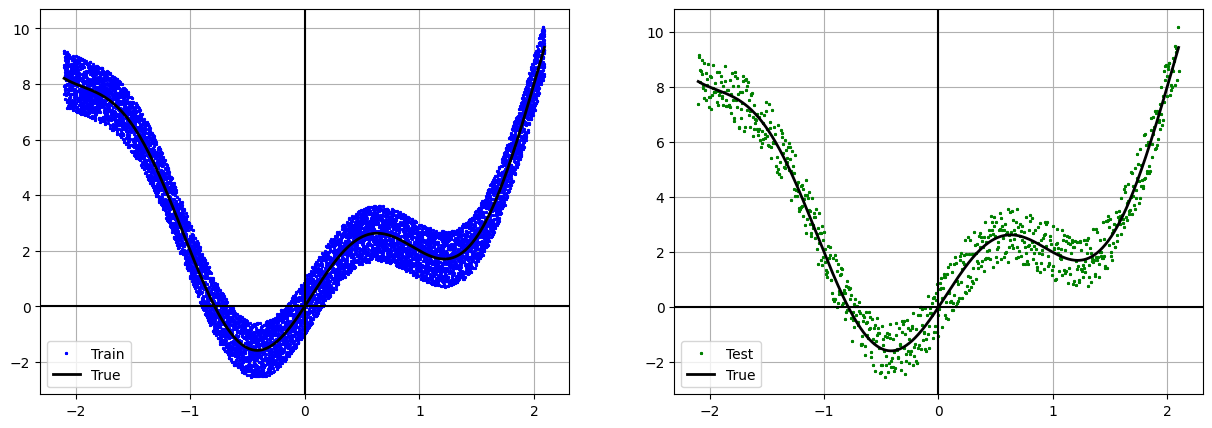

In [30]:
fig, axes = plt.subplots(1, 2, figsize =(15,5))

ax = axes[0]
ax.plot(X_train, y_train, 'b*', markersize=2, label = 'Train')
ax.plot(X_train,  y_true, c = 'k', linewidth=2, label = 'True')
ax.axhline(0, c = 'k')
ax.axvline(0, c = 'k')
ax.grid()
ax.legend()

ax = axes[1]
ax.plot(X_test, y_test, 'g*', markersize=2, label = 'Test')
ax.plot(X_test,  y_true_test, c = 'k', linewidth=2, label = 'True')
ax.axhline(0, c = 'k')
ax.axvline(0, c = 'k')
ax.grid()
ax.legend();

In [31]:
# Prepare data loaders
X_train_tensor = torch.FloatTensor(X_train).reshape(-1, 1)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [32]:
class Swish(nn.Module):
    """Swish activation function: x * sigmoid(x)"""
    def forward(self, x):
        return x * torch.sigmoid(x)

In [33]:
class RegressionMLP(nn.Module):

    """MLP for regression with ReLU activation"""
    
    def __init__(self, input_dim=1, hidden_dims=[128, 64]):

        super(RegressionMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(Swish())
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [34]:
def train_model(model, 
                train_loader, 
                test_loader, 
                epochs=EPOCHS, 
                lr=ALPHA):
    """Train a PyTorch model and return history"""
    loss_fn = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    
    history = {'epoch': [],
               'train_loss': [],
               'test_loss': [],
               'train_err': [],
               'test_err': []}
    
    for epoch in range(epochs):
        history['epoch'].append(epoch)
        
        # Training phase
        model.train()
        train_loss = 0.0
        train_err = 0.0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            batch_loss = loss_fn(outputs.squeeze(), batch_y)
            batch_loss.backward()
            optimizer.step()
            
            # Detach before converting to numpy
            batch_err = mean_squared_error(
                batch_y.detach().cpu().numpy(), 
                outputs.detach().cpu().numpy()
            )
            train_loss += batch_loss.item() * batch_X.size(0)
            train_err += batch_err * batch_X.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_err /= len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        history['train_err'].append(train_err)

        # Validation phase
        model.eval()
        test_loss = 0.0
        test_err = 0.0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = loss_fn(outputs.squeeze(), batch_y)
                
                # No need to detach since no_grad already prevents gradient tracking
                batch_err = mean_squared_error(
                    batch_y.cpu().numpy(), 
                    outputs.cpu().numpy()
                )
                test_loss += loss.item() * batch_X.size(0)
                test_err += batch_err * batch_X.size(0)
        
        test_loss /= len(test_loader.dataset)
        test_err /= len(test_loader.dataset)
        history['test_loss'].append(test_loss)
        history['test_err'].append(test_err)

        if epoch % 10 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {train_loss:.4f} / {test_loss:.4f} | Train Err: {train_err:.4f} / Test Err: {test_err:.4f}')
    
    return history

In [35]:
model = RegressionMLP(input_dim=1, 
                      hidden_dims=[128, 64]
                      ).to(device)


In [36]:

history = train_model(model, 
                           train_loader, 
                           test_loader, 
                           epochs=EPOCHS)

Epoch [0/51], Loss: 3.1181 / 1.5191 | Train Err: 3.1181 / Test Err: 1.5191
Epoch [10/51], Loss: 0.3762 / 0.3988 | Train Err: 0.3762 / Test Err: 0.3988
Epoch [20/51], Loss: 0.3652 / 0.3552 | Train Err: 0.3652 / Test Err: 0.3552
Epoch [30/51], Loss: 0.3572 / 0.3520 | Train Err: 0.3572 / Test Err: 0.3520
Epoch [40/51], Loss: 0.3566 / 0.3877 | Train Err: 0.3566 / Test Err: 0.3877
Epoch [50/51], Loss: 0.3547 / 0.3674 | Train Err: 0.3547 / Test Err: 0.3674


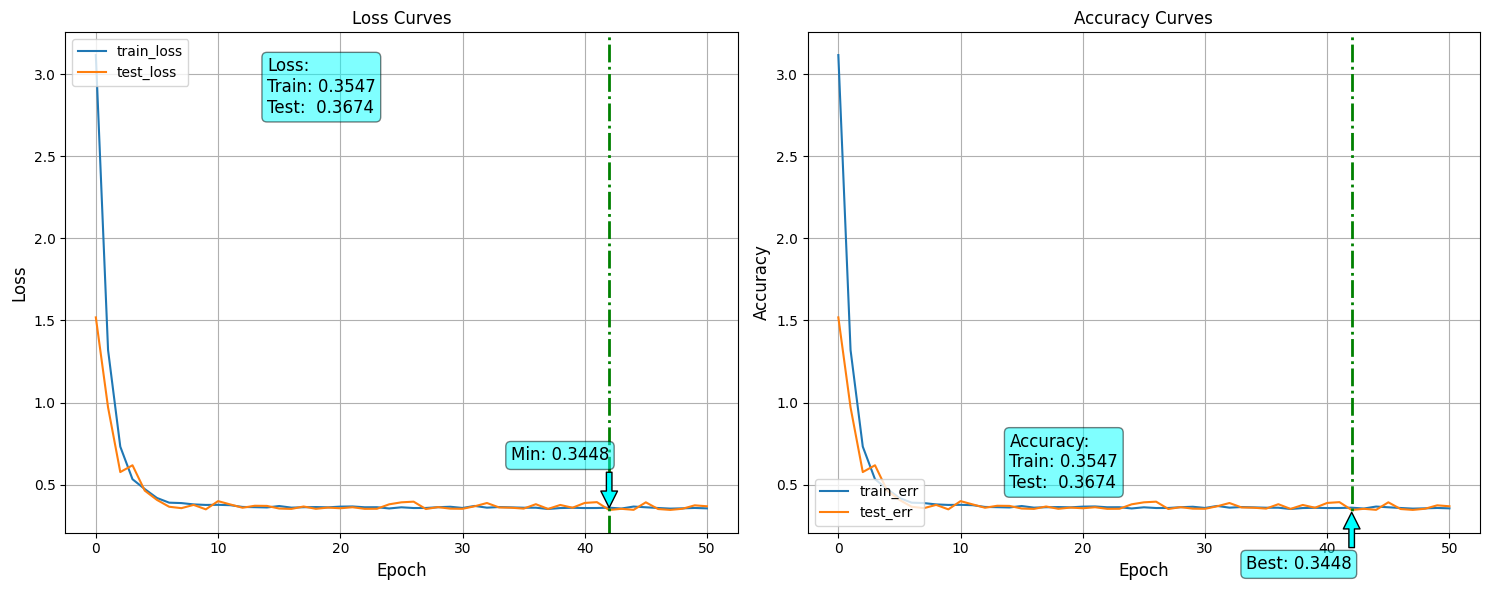

In [37]:
hist_df = pd.DataFrame(history)

fn_plot_torch_hist(hist_df)

In [38]:
# Evaluate Model 1
model.eval()
with torch.inference_mode():
    y_pred = model(X_test_tensor.to(device)).cpu().numpy()
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f'Loss (MSE): {mse:.3f}, RMSE: {rmse:.3f}')

Loss (MSE): 0.367, RMSE: 0.606


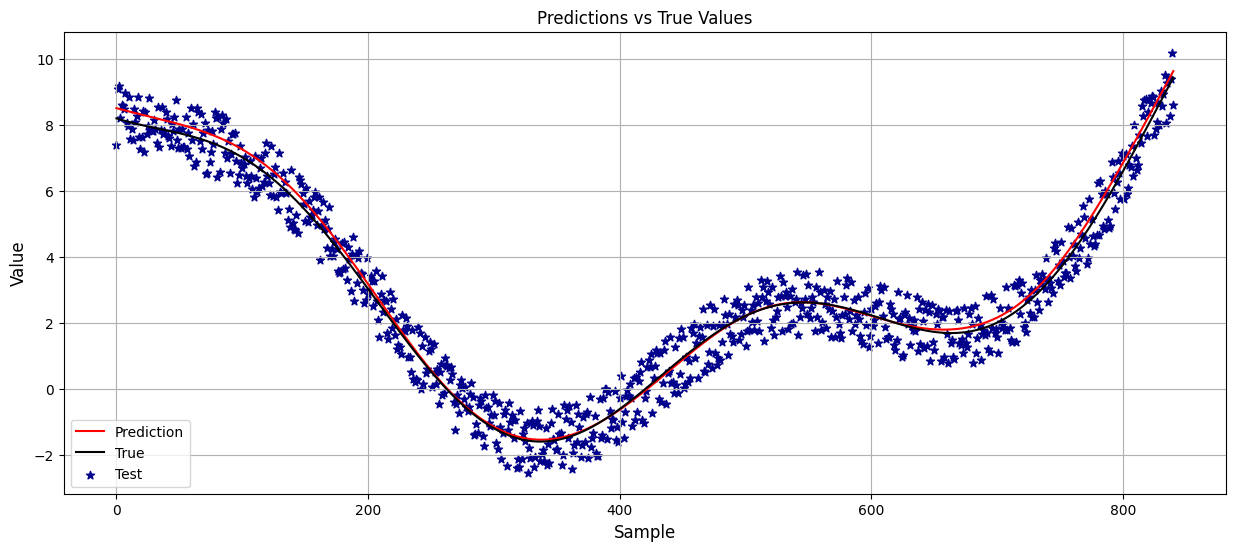

In [39]:
 # Plot predictions

results_df = pd.DataFrame({
    'pred': y_pred[:, 0],
    'test': y_test,
    'y_true': y_true_test
})

fig, ax = plt.subplots(figsize=(15, 6))
results_df['pred'].plot(c='r', label='Prediction', ax=ax)
results_df['y_true'].plot(c='k', label='True', ax=ax)
plt.scatter(results_df.index, results_df['test'], c='darkblue', marker='*', label='Test')
ax.set_xlabel('Sample')
ax.set_ylabel('Value')
ax.grid()
plt.legend()
plt.title('Predictions vs True Values')
plt.show()